In [1]:
from urllib.request import urlopen, Request
from urllib.error import HTTPError
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import nltk
import joblib

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\shruti\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [2]:
finviz_url = 'https://finviz.com/quote.ashx?t='
tickers = ['AMZN', 'GOOG', 'META']

news_tables = {}
for ticker in tickers:
    url = finviz_url + ticker
    try:
        req = Request(url=url, headers={'user-agent': 'Mozilla/5.0'})
        response = urlopen(req)
        html = BeautifulSoup(response, features='html.parser')
        news_table = html.find(id='news-table')
        
        if news_table:
            news_tables[ticker] = news_table
        else:
            print(f"[!] News table not found for {ticker}")
            
    except HTTPError as e:
        print(f"[X] HTTP Error for {ticker}: {e.code} - {e.reason}")
    except Exception as ex:
        print(f"[X] Failed for {ticker}: {ex}")


In [3]:
parsed_data = []

for ticker, news_table in news_tables.items():
    for row in news_table.findAll('tr'):
        title = row.a.text.strip()
        date_data = row.td.text.strip().split(' ')
        
        if len(date_data) == 1:
            date_str = datetime.now().strftime("%b-%d-%y")
            time = date_data[0]
        else:
            date_str = date_data[0]
            time = date_data[1]

        try:
            date = datetime.strptime(date_str, "%b-%d-%y").date()
        except ValueError:
            continue

        parsed_data.append([ticker, date, time, title])

# Convert to DataFrame
df = pd.DataFrame(parsed_data, columns=['ticker', 'date', 'time', 'title'])
df['date'] = pd.to_datetime(df['date']).dt.date


In [4]:
# Load models
nb_model = joblib.load('naive_bayes_model.pkl')
log_model = joblib.load('logistic_model.pkl')
svm_model = joblib.load('svm_model.pkl')

# Predict using Naive Bayes
df['nb_sentiment'] = nb_model.predict(df['title'])

# Predict using Logistic Regression
df['log_sentiment'] = log_model.predict(df['title'])

# Predict using SVM
df['svm_sentiment'] = svm_model.predict(df['title'])

# Map sentiments to numeric scores
sentiment_map = {'positive': 1, 'neutral': 0, 'negative': -1}
df['nb_score'] = df['nb_sentiment'].map(sentiment_map)
df['log_score'] = df['log_sentiment'].map(sentiment_map)
df['svm_score'] = df['svm_sentiment'].map(sentiment_map)

C:\Users\shruti\AppData\Local\Temp\ipykernel_9876\2260141155.py:15: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()


<Figure size 1400x600 with 0 Axes>

C:\Users\shruti\anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


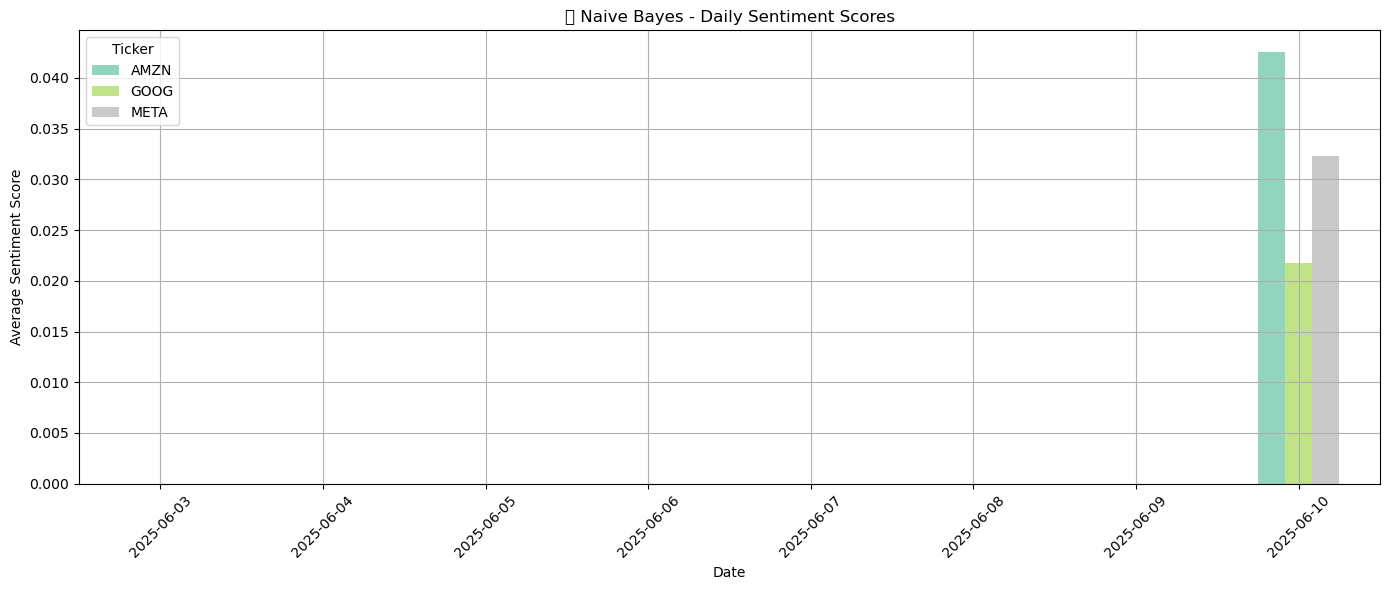

C:\Users\shruti\AppData\Local\Temp\ipykernel_9876\2260141155.py:26: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()


<Figure size 1400x600 with 0 Axes>

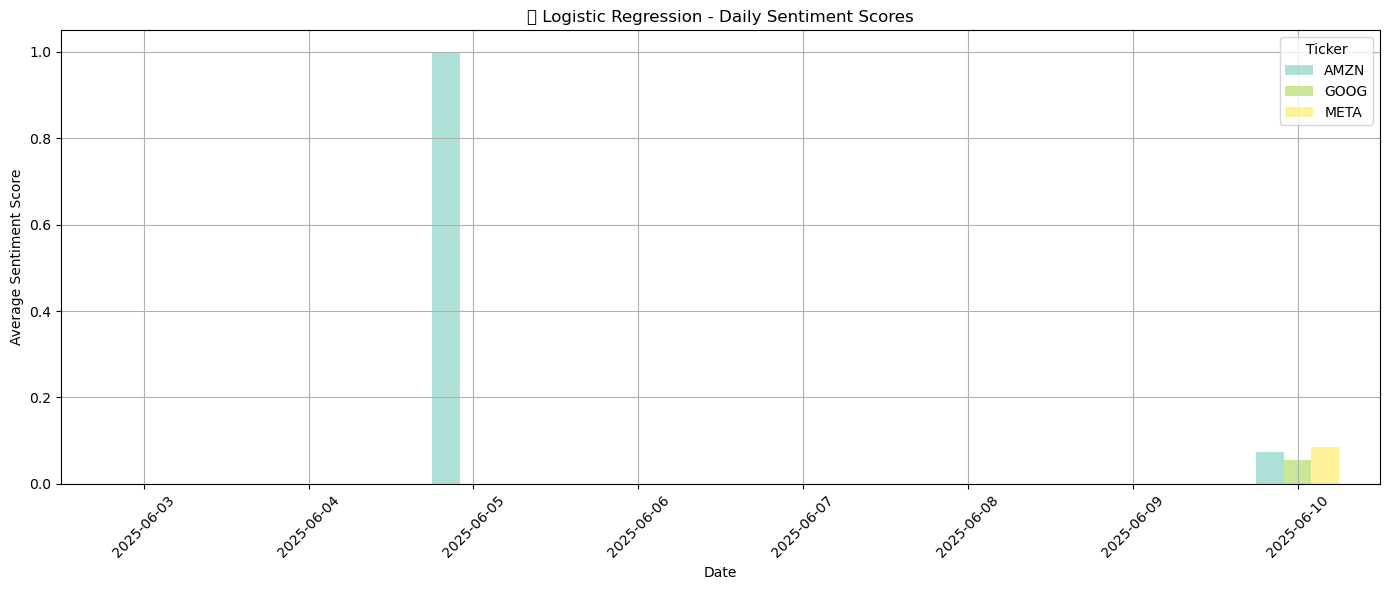

C:\Users\shruti\AppData\Local\Temp\ipykernel_9876\2260141155.py:37: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()


<Figure size 1400x600 with 0 Axes>

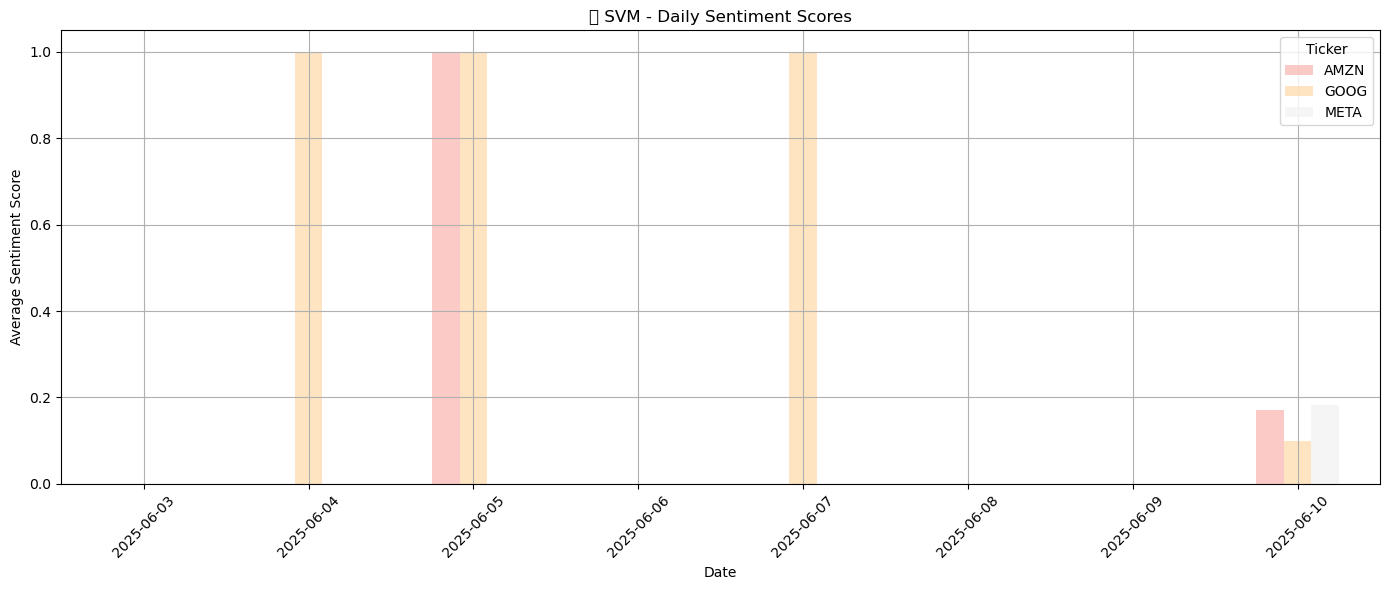

In [5]:
# Group and average scores by ticker and date
nb_mean = df.groupby(['ticker', 'date'])['nb_score'].mean().unstack()
log_mean = df.groupby(['ticker', 'date'])['log_score'].mean().unstack()
svm_mean = df.groupby(['ticker', 'date'])['svm_score'].mean().unstack()

# Plot
plt.figure(figsize=(14, 6))
nb_mean.T.plot(kind='bar', colormap="Set2", figsize=(14,6), alpha=0.7)
plt.title("📊 Naive Bayes - Daily Sentiment Scores")
plt.xlabel("Date")
plt.ylabel("Average Sentiment Score")
plt.legend(title="Ticker")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
log_mean.T.plot(kind='bar', colormap="Set3", figsize=(14,6), alpha=0.7)
plt.title("📊 Logistic Regression - Daily Sentiment Scores")
plt.xlabel("Date")
plt.ylabel("Average Sentiment Score")
plt.legend(title="Ticker")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
svm_mean.T.plot(kind='bar', colormap="Pastel1", figsize=(14,6), alpha=0.7)
plt.title("📊 SVM - Daily Sentiment Scores")
plt.xlabel("Date")
plt.ylabel("Average Sentiment Score")
plt.legend(title="Ticker")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [6]:
# Viewing Predicted Headlines
df[['ticker', 'date', 'time', 'title', 'nb_sentiment', 'log_sentiment']].head(10)


,ticker,date,time,title,nb_sentiment,log_sentiment
0,AMZN,2025-06-10,06:00AM,IBM just took a 'significant' step toward usef...,neutral,neutral
1,AMZN,2025-06-10,05:30AM,Apple Fails to Clear a Low Bar on AI,neutral,neutral
2,AMZN,2025-06-10,05:12AM,Warren Buffett Has 23% of Berkshire Hathaway's...,neutral,positive
3,AMZN,2025-06-10,05:00AM,Lawmakers Traded Stocks Heavily as Trump Rolle...,neutral,neutral
4,AMZN,2025-06-10,04:30AM,3 Brilliant Growth Stocks to Buy Now and Hold ...,neutral,positive
5,AMZN,2025-06-10,04:28AM,"The Zacks Analyst Blog Highlights Amazon, Walm...",neutral,neutral
6,AMZN,2025-06-10,04:00AM,Reddit brands Anthropic as 'anything but' a wh...,neutral,neutral
7,AMZN,2025-06-10,03:06AM,Apple vs. Amazon: Which Warren Buffet AI Stock...,neutral,neutral
8,AMZN,2025-06-09,09:16PM,Amazon Pledges $20 Billion for Pennsylvania Da...,neutral,neutral
9,AMZN,2025-06-10,08:56PM,"Want $1 Million in Retirement? Invest $100,000...",neutral,neutral
